# Person 2 — Step 5: Advanced Dual-Track Thumbnail Analysis

Two parallel pipelines that together characterise the *DNA* of each channel group's visual communication strategy.

| Track | Tool | Granularity | Sample |
|-------|------|-------------|--------|
| 1 | **Ollama + qwen2.5vl:7b** (local GPU) | Semantic/textual — structured JSON | All 9 568 |
| 2 | **DINOv2** (facebook/dinov2-base) | Visual/spatial — embeddings → clusters | All 9 568 |

**Synthesis**: cross-reference both tracks to define canonical Thumbnail Archetypes.

> **Setup**: run the code cell below — it installs missing packages and pulls the model automatically.

In [1]:
import subprocess, sys

# ── Python packages ───────────────────────────────────────────────────────────
for pkg in ['ollama', 'umap-learn']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# ── Ollama model ──────────────────────────────────────────────────────────────
# qwen2.5vl is the correct Ollama tag (no dash between 2.5 and vl)
# Alternatives if it fails: 'llava:7b', 'minicpm-v:8b'
OLLAMA_MODEL = 'qwen2.5vl:7b'

import ollama as _ollama_check
pulled = [m['model'] for m in _ollama_check.list()['models']]

if OLLAMA_MODEL not in pulled:
    print(f'Pulling {OLLAMA_MODEL} (~5 GB, one-time download)...')
    subprocess.run(['ollama', 'pull', OLLAMA_MODEL], check=True)
    print('Done.')
else:
    print(f'✓  {OLLAMA_MODEL} already available.')

print(f'Available models: {pulled}')

Installing umap-learn...
✓  qwen2.5vl:7b already available.
Available models: ['qwen2.5vl:7b']


In [2]:
import os
# Cap OpenBLAS threads before NumPy loads to suppress "NUM_THREADS exceeded" warnings
os.environ.setdefault('OPENBLAS_NUM_THREADS', '8')
os.environ.setdefault('OMP_NUM_THREADS', '8')

import sys, json, time
from pathlib import Path
from typing import Literal

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from tqdm.notebook import tqdm
import cv2
from PIL import Image
import torch
from pydantic import BaseModel, Field
import ollama

sys.path.append('../../')
from shared.config import PERSON2_DIR, THUMBNAILS_DIR

FIGURES = PERSON2_DIR / 'outputs' / 'figures'
TABLES  = PERSON2_DIR / 'outputs' / 'tables'
MANIFEST = PERSON2_DIR / 'outputs' / 'thumbnail_manifest.csv'

PALETTE = {'independent': '#2ecc71', 'institutional': '#3498db'}
# OLLAMA_MODEL is set in the setup cell above — change it there if needed
print(f'Using model: {OLLAMA_MODEL}')

Using model: qwen2.5vl:7b


In [3]:
manifest = pd.read_csv(MANIFEST)
manifest = manifest[manifest['thumb_path'].apply(lambda p: Path(p).exists())].copy()
opencv_df = pd.read_csv(TABLES / 'opencv_features.csv')
clip_df   = pd.read_csv(TABLES / 'clip_features.csv')

merged = (manifest
          .merge(opencv_df, on='video_id')
          .merge(clip_df,   on='video_id'))

print(f"Loaded {len(merged)} thumbnails")
print(merged.groupby(['group_label', 'channel_title']).size().to_string())

Loaded 9568 thumbnails
group_label    channel_title                                          
independent    3Blue1Brown                                                 229
               Kurzgesagt – In a Nutshell                                  350
               Lectures by Walter Lewin. They will make you ♥ Physics.    1665
               minutephysics                                               304
institutional  EPFL                                                        704
               ETH Zürich                                                 1178
               Massachusetts Institute of Technology (MIT)                 946
               Stanford                                                   4192


---
## TRACK 1 — VLM Structured Semantic Analysis (local Ollama)

`qwen2.5-vl:7b` is called locally via the Ollama Python client with `format=schema`, which forces the model to return a JSON object matching the Pydantic schema exactly — no API key, no network latency, no cost per call.

In [4]:
# ── Pydantic models (for local validation after parsing) ─────────────────────
class HumanPresence(BaseModel):
    is_present: bool
    count: int
    canvas_coverage_percentage: int = Field(..., ge=0, le=100)
    dominant_emotion: Literal[
        'none', 'neutral', 'shock_or_surprise',
        'excitement', 'seriousness_or_intense', 'fear_or_worry'
    ]

class ClickbaitIndicators(BaseModel):
    has_red_arrow_or_circle: bool
    has_exaggerated_contrast: bool
    subjective_sensationalism_score: int = Field(..., ge=1, le=5)

class ThumbnailAnalysis(BaseModel):
    embedded_text: str
    text_function: Literal[
        'none', 'question', 'factual_statement', 'hyperbolic_hook', 'label_or_acronym'
    ]
    primary_scientific_subject: str
    visual_presentation_style: Literal[
        'academic_lecture', 'cgi_render', 'pop_illustration',
        'vlog_selfie', 'stock_photography', 'minimalist_text'
    ]
    text_placement_zone: Literal[
        'none', 'top', 'bottom', 'left', 'right', 'center', 'full_overlay'
    ]
    human_presence: HumanPresence
    clickbait_indicators: ClickbaitIndicators

print('Pydantic models defined.')

Pydantic models defined.


In [5]:
# Ollama structured output uses the Pydantic JSON schema directly.
# No API key or tool-use wiring needed — the local engine enforces the schema.

VLM_PROMPT = (
    "You are an expert quantitative media researcher specialising in visual framing "
    "and social media science communication. Analyse the provided YouTube thumbnail "
    "image and extract the following features. Be objective — base all assessments "
    "strictly on visual evidence in the image.\n\n"
    "Field definitions:\n"
    "- embedded_text: exact transcription of any text rendered on the image (empty string if none).\n"
    "- text_function: rhetorical purpose of the text — "
      "'none' | 'question' | 'factual_statement' | 'hyperbolic_hook' | 'label_or_acronym'.\n"
    "- primary_scientific_subject: core concept or field depicted (e.g. 'black hole', 'DNA').\n"
    "- visual_presentation_style: dominant aesthetic — "
      "'academic_lecture' | 'cgi_render' | 'pop_illustration' | "
      "'vlog_selfie' | 'stock_photography' | 'minimalist_text'.\n"
    "- text_placement_zone: where text is anchored — "
      "'none' | 'top' | 'bottom' | 'left' | 'right' | 'center' | 'full_overlay'.\n"
    "- human_presence.is_present: boolean.\n"
    "- human_presence.count: number of distinct faces visible.\n"
    "- human_presence.canvas_coverage_percentage: estimated % of thumbnail area covered by faces/bodies (0-100).\n"
    "- human_presence.dominant_emotion: "
      "'none' | 'neutral' | 'shock_or_surprise' | 'excitement' | 'seriousness_or_intense' | 'fear_or_worry'.\n"
    "- clickbait_indicators.has_red_arrow_or_circle: true if graphic arrows/circles highlight an object.\n"
    "- clickbait_indicators.has_exaggerated_contrast: true if elements are heavily photoshopped or glowed.\n"
    "- clickbait_indicators.subjective_sensationalism_score: integer 1-5 "
      "(1=purely academic/neutral, 5=extreme sensationalism/curiosity gap)."
)

# Pass the full Pydantic schema — Ollama enforces this at the engine level
VLM_SCHEMA = ThumbnailAnalysis.model_json_schema()
print('VLM prompt and schema ready.')

VLM prompt and schema ready.


In [6]:
def flatten_vlm_result(r: dict, video_id: str, channel_title: str, group_label: str) -> dict:
    """Flatten nested human_presence / clickbait_indicators dicts for CSV storage."""
    flat = {
        'video_id':                   video_id,
        'channel_title':              channel_title,
        'group_label':                group_label,
        'embedded_text':              r.get('embedded_text', ''),
        'text_function':              r.get('text_function', ''),
        'primary_scientific_subject': r.get('primary_scientific_subject', ''),
        'visual_presentation_style':  r.get('visual_presentation_style', ''),
        'text_placement_zone':        r.get('text_placement_zone', ''),
    }
    hp = r.get('human_presence', {})
    flat['hp_is_present']          = hp.get('is_present', False)
    flat['hp_count']               = hp.get('count', 0)
    flat['hp_canvas_coverage_pct'] = hp.get('canvas_coverage_percentage', 0)
    flat['hp_dominant_emotion']    = hp.get('dominant_emotion', 'none')

    cb = r.get('clickbait_indicators', {})
    flat['cb_has_red_arrow']        = cb.get('has_red_arrow_or_circle', False)
    flat['cb_has_exag_contrast']    = cb.get('has_exaggerated_contrast', False)
    flat['cb_sensationalism_score'] = cb.get('subjective_sensationalism_score', 1)
    return flat


def analyse_thumbnail_vlm(path: str, max_retries: int = 3) -> dict | None:
    for attempt in range(max_retries):
        try:
            response = ollama.chat(
                model=OLLAMA_MODEL,
                messages=[{
                    'role':    'user',
                    'content': VLM_PROMPT,
                    'images':  [path],   # Ollama accepts file paths directly
                }],
                format=VLM_SCHEMA,       # engine-level JSON schema enforcement
                options={'temperature': 0.1},
            )
            raw = response['message']['content']
            return json.loads(raw)
        except json.JSONDecodeError as e:
            print(f'JSON parse error (attempt {attempt+1}): {e}')
            if attempt < max_retries - 1:
                time.sleep(1)
        except Exception as e:
            print(f'Error on {path} (attempt {attempt+1}): {e}')
            if attempt < max_retries - 1:
                time.sleep(2)
    return None


print('Ollama VLM helper functions defined.')

Ollama VLM helper functions defined.


In [7]:
VLM_OUTPUT = TABLES / 'vlm_thumbnail_analysis.csv'

sample = manifest.copy()
print(f"Using all {len(sample)} thumbnails across {sample['channel_title'].nunique()} channels")
print(sample.groupby(['group_label', 'channel_title']).size().to_string())

Using all 9568 thumbnails across 8 channels
group_label    channel_title                                          
independent    3Blue1Brown                                                 229
               Kurzgesagt – In a Nutshell                                  350
               Lectures by Walter Lewin. They will make you ♥ Physics.    1665
               minutephysics                                               304
institutional  EPFL                                                        704
               ETH Zürich                                                 1178
               Massachusetts Institute of Technology (MIT)                 946
               Stanford                                                   4192


In [8]:
# Runs fully locally — no API key, no rate limiting, GPU-accelerated

already_done: set[str] = set()
if VLM_OUTPUT.exists():
    done_df = pd.read_csv(VLM_OUTPUT)
    already_done = set(done_df['video_id'].tolist())
    print(f"Resuming: {len(already_done)} done, {len(sample) - len(already_done)} remaining")
else:
    print(f"Starting fresh — {len(sample)} thumbnails to process")

new_rows = []
for _, row in tqdm(sample.iterrows(), total=len(sample), desc=f'VLM ({OLLAMA_MODEL})'):
    if row['video_id'] in already_done:
        continue
    result = analyse_thumbnail_vlm(row['thumb_path'])
    if result:
        flat = flatten_vlm_result(
            result, row['video_id'], row['channel_title'], row['group_label']
        )
        new_rows.append(flat)

if new_rows:
    new_df = pd.DataFrame(new_rows)
    if VLM_OUTPUT.exists():
        new_df = pd.concat([pd.read_csv(VLM_OUTPUT), new_df], ignore_index=True)
    new_df.to_csv(VLM_OUTPUT, index=False)
    print(f"Saved {len(new_df)} rows → {VLM_OUTPUT.name}")
else:
    print('No new rows to write.')

Resuming: 400 done, 9168 remaining


VLM (qwen2.5vl:7b):   0%|          | 0/9568 [00:00<?, ?it/s]

JSON parse error (attempt 1): Unterminated string starting at: line 2 column 20 (char 21)
JSON parse error (attempt 2): Unterminated string starting at: line 2 column 20 (char 21)
JSON parse error (attempt 3): Unterminated string starting at: line 2 column 20 (char 21)
JSON parse error (attempt 1): Unterminated string starting at: line 2 column 20 (char 21)
Error on /Users/alexlag/Documents/MA2/CompSocialMedia/YouTubeCompare/analysis/person2_titles_thumbnails/../../analysis/person2_titles_thumbnails/thumbnails/0GY_RHEBPVs.jpg (attempt 1): an error was encountered while running the model: GGML_ASSERT(a->ne[2] * 4 == b->ne[0]) failed
signal arrived during cgo execution
GGML_ASSERT([rsets->data count] == 0) failed (status code: 500)
Error on /Users/alexlag/Documents/MA2/CompSocialMedia/YouTubeCompare/analysis/person2_titles_thumbnails/../../analysis/person2_titles_thumbnails/thumbnails/0GY_RHEBPVs.jpg (attempt 2): an error was encountered while running the model: GGML_ASSERT(a->ne[2] * 4 

In [10]:
vlm_df = pd.read_csv(VLM_OUTPUT)
print(f"VLM dataset: {len(vlm_df)} rows")
print(f"Groups: {vlm_df['group_label'].value_counts().to_dict()}")
vlm_df.head(3)

VLM dataset: 9486 rows
Groups: {'institutional': 6965, 'independent': 2521}


,video_id,channel_title,group_label,embedded_text,text_function,primary_scientific_subject,visual_presentation_style,text_placement_zone,hp_is_present,hp_count,hp_canvas_coverage_pct,hp_dominant_emotion,cb_has_red_arrow,cb_has_exag_contrast,cb_sensationalism_score
0,w-CXIqIjfRI,3Blue1Brown,independent,Levels of u\nWhat is it saying?\nWhy is it tru...,question,Bayesian inference,academic_lecture,top,False,0,0,none,False,False,1
1,Iq1a_KJTWJ8,3Blue1Brown,independent,\frac{\sin(\theta_1)}{v_1} = \frac{\sin(\theta...,factual_statement,wave mechanics,academic_lecture,center,False,0,0,none,False,False,1
2,1lZpowy21Gc,3Blue1Brown,independent,NaN,none,minimalist_text,stock_photography,none,False,0,0,none,False,False,1


### 1a — Text Function Distribution

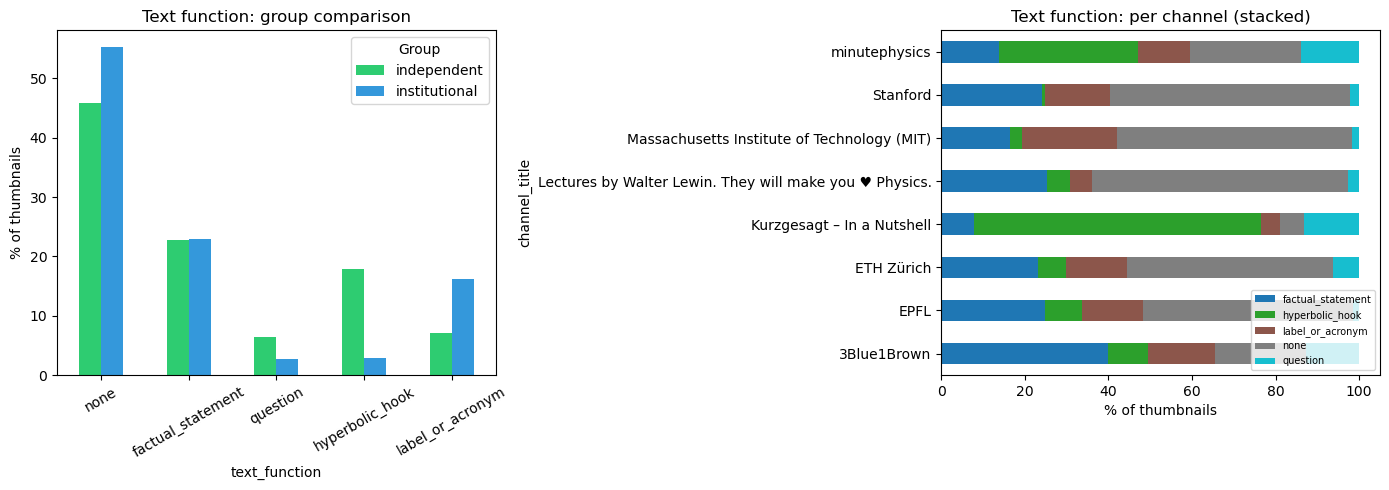

Chi-square test (text_function × group): χ²=817.37, df=4, p=0.0000


In [11]:
tf_order = ['none', 'factual_statement', 'question', 'hyperbolic_hook', 'label_or_acronym']

tf_pct = (
    vlm_df.groupby(['group_label', 'text_function'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[c for c in tf_order if c in vlm_df['text_function'].unique()], fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tf_pct.T.plot(kind='bar', ax=axes[0],
              color=[PALETTE.get(g.lower(), 'grey') for g in tf_pct.index], rot=30)
axes[0].set_ylabel('% of thumbnails')
axes[0].set_title('Text function: group comparison')
axes[0].legend(title='Group')

# Per-channel breakdown
ch_tf = (
    vlm_df.groupby(['channel_title', 'text_function'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
)
ch_tf.plot(kind='barh', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_xlabel('% of thumbnails')
axes[1].set_title('Text function: per channel (stacked)')
axes[1].legend(loc='lower right', fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES / 'vlm_text_function.png', dpi=150)
plt.show()

# Chi-square test
ct = pd.crosstab(vlm_df['group_label'], vlm_df['text_function'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square test (text_function × group): χ²={chi2:.2f}, df={dof}, p={p:.4f}")

### 1b — Visual Presentation Style

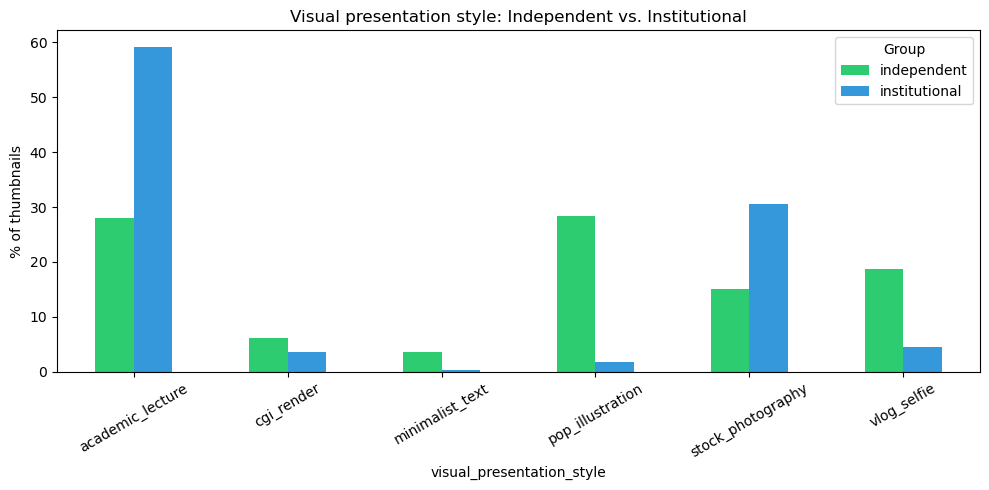

Chi-square (visual_presentation_style × group): χ²=2657.48, df=5, p=0.0000


In [12]:
style_pct = (
    vlm_df.groupby(['group_label', 'visual_presentation_style'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
)

fig, ax = plt.subplots(figsize=(10, 5))
style_pct.T.plot(kind='bar', ax=ax,
                 color=[PALETTE.get(g.lower(), 'grey') for g in style_pct.index], rot=30)
ax.set_ylabel('% of thumbnails')
ax.set_title('Visual presentation style: Independent vs. Institutional')
ax.legend(title='Group')
plt.tight_layout()
plt.savefig(FIGURES / 'vlm_presentation_style.png', dpi=150)
plt.show()

ct2 = pd.crosstab(vlm_df['group_label'], vlm_df['visual_presentation_style'])
chi2, p, dof, _ = stats.chi2_contingency(ct2)
print(f"Chi-square (visual_presentation_style × group): χ²={chi2:.2f}, df={dof}, p={p:.4f}")

### 1c — Human Presence & Emotion

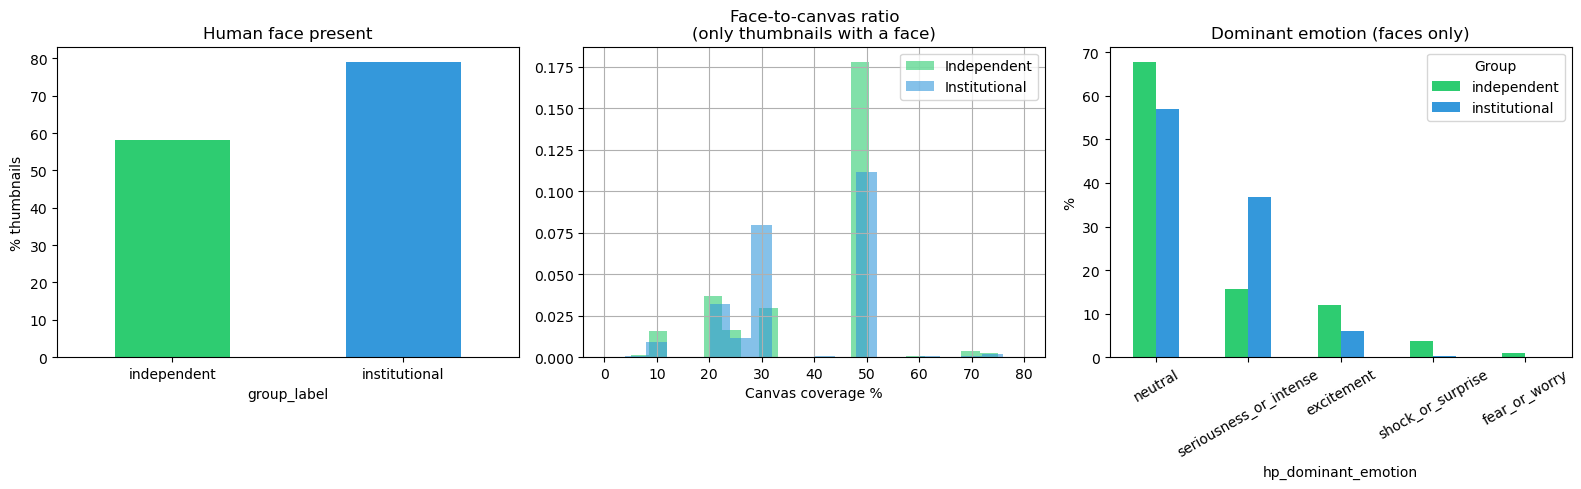

Mann-Whitney U (canvas coverage pct): U=4551313, p=0.0000
Median coverage — independent: 50%  institutional: 30%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (i) % thumbnails with a human face
face_pct = vlm_df.groupby('group_label')['hp_is_present'].mean() * 100
face_pct.plot(kind='bar', ax=axes[0],
              color=[PALETTE[g.lower()] for g in face_pct.index], rot=0)
axes[0].set_ylabel('% thumbnails')
axes[0].set_title('Human face present')

# (ii) Face-to-canvas coverage (among thumbnails WITH a face)
with_face = vlm_df[vlm_df['hp_is_present']]
for grp, color in PALETTE.items():
    vals = with_face[with_face['group_label'].str.lower() == grp]['hp_canvas_coverage_pct']
    vals.hist(ax=axes[1], bins=20, alpha=0.6, color=color, label=grp.title(), density=True)
axes[1].set_xlabel('Canvas coverage %')
axes[1].set_title('Face-to-canvas ratio\n(only thumbnails with a face)')
axes[1].legend()

# (iii) Emotion breakdown (among thumbnails with face)
emotion_order = ['neutral', 'seriousness_or_intense', 'excitement', 'shock_or_surprise', 'fear_or_worry']
emo_pct = (
    with_face.groupby(['group_label', 'hp_dominant_emotion'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
    .reindex(columns=[c for c in emotion_order if c in with_face['hp_dominant_emotion'].unique()],
             fill_value=0)
)
emo_pct.T.plot(kind='bar', ax=axes[2],
               color=[PALETTE.get(g.lower(), 'grey') for g in emo_pct.index], rot=30)
axes[2].set_ylabel('%')
axes[2].set_title('Dominant emotion (faces only)')
axes[2].legend(title='Group')

plt.tight_layout()
plt.savefig(FIGURES / 'vlm_human_presence.png', dpi=150)
plt.show()

# Mann-Whitney U on canvas coverage
ind_cov = with_face[with_face['group_label'].str.lower() == 'independent']['hp_canvas_coverage_pct']
ins_cov = with_face[with_face['group_label'].str.lower() == 'institutional']['hp_canvas_coverage_pct']
u, p_mw = stats.mannwhitneyu(ind_cov, ins_cov, alternative='two-sided')
print(f"Mann-Whitney U (canvas coverage pct): U={u:.0f}, p={p_mw:.4f}")
print(f"Median coverage — independent: {ind_cov.median():.0f}%  institutional: {ins_cov.median():.0f}%")

### 1d — Clickbait Indicators & Sensationalism Score

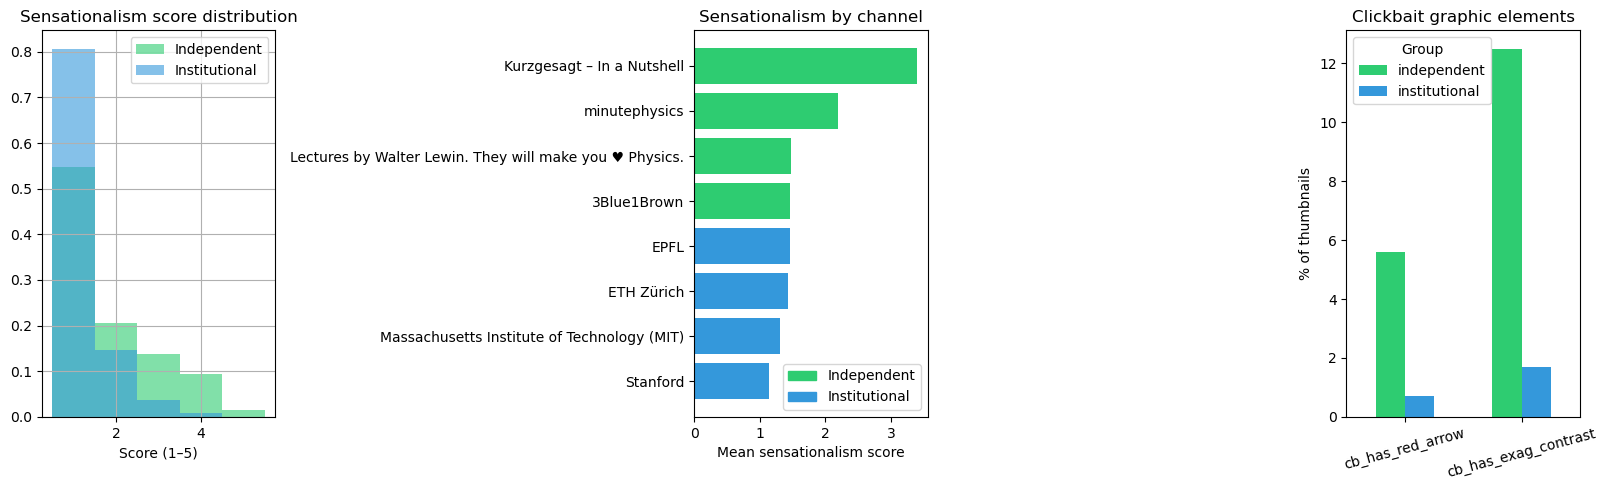

Mann-Whitney U (sensationalism score): U=11323350, p=0.0000
Mean — independent: 1.82  institutional: 1.25


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (i) Sensationalism score distribution
for grp, color in PALETTE.items():
    vals = vlm_df[vlm_df['group_label'].str.lower() == grp]['cb_sensationalism_score']
    vals.hist(ax=axes[0], bins=5, range=(0.5, 5.5), alpha=0.6, color=color,
              label=grp.title(), density=True)
axes[0].set_xlabel('Score (1–5)')
axes[0].set_title('Sensationalism score distribution')
axes[0].legend()

# (ii) Mean sensationalism by channel
ch_score = vlm_df.groupby(['channel_title', 'group_label'])['cb_sensationalism_score'].mean().reset_index()
ch_score = ch_score.sort_values('cb_sensationalism_score', ascending=True)
colors = [PALETTE.get(g.lower(), 'grey') for g in ch_score['group_label']]
axes[1].barh(ch_score['channel_title'], ch_score['cb_sensationalism_score'], color=colors)
axes[1].set_xlabel('Mean sensationalism score')
axes[1].set_title('Sensationalism by channel')
ind_patch = mpatches.Patch(color=PALETTE['independent'], label='Independent')
ins_patch = mpatches.Patch(color=PALETTE['institutional'], label='Institutional')
axes[1].legend(handles=[ind_patch, ins_patch])

# (iii) Binary clickbait indicators
binary_cols = ['cb_has_red_arrow', 'cb_has_exag_contrast']
bin_means = vlm_df.groupby('group_label')[binary_cols].mean() * 100
bin_means.T.plot(kind='bar', ax=axes[2],
                 color=[PALETTE.get(g.lower(), 'grey') for g in bin_means.index], rot=15)
axes[2].set_ylabel('% of thumbnails')
axes[2].set_title('Clickbait graphic elements')
axes[2].legend(title='Group')

plt.tight_layout()
plt.savefig(FIGURES / 'vlm_clickbait.png', dpi=150)
plt.show()

# Mann-Whitney U on sensationalism score
ind_s = vlm_df[vlm_df['group_label'].str.lower() == 'independent']['cb_sensationalism_score']
ins_s = vlm_df[vlm_df['group_label'].str.lower() == 'institutional']['cb_sensationalism_score']
u, p_s = stats.mannwhitneyu(ind_s, ins_s, alternative='two-sided')
print(f"Mann-Whitney U (sensationalism score): U={u:.0f}, p={p_s:.4f}")
print(f"Mean — independent: {ind_s.mean():.2f}  institutional: {ins_s.mean():.2f}")

---
## TRACK 2 — DINOv2 Visual Embeddings & Archetype Clustering

DINOv2 (ViT-B/14) is a self-supervised vision transformer trained on 142M images. Its CLS token produces a 768-dimensional embedding that captures layout, texture, and colour structure without any label supervision — ideal for discovering visual archetypes.

In [15]:
from transformers import AutoImageProcessor, AutoModel

DINO_EMB_CACHE = TABLES / 'dinov2_embeddings.npy'
DINO_IDS_CACHE = TABLES / 'dinov2_video_ids.csv'

DEVICE = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f"DINOv2 will run on: {DEVICE}")

if DINO_EMB_CACHE.exists() and DINO_IDS_CACHE.exists():
    emb_matrix = np.load(DINO_EMB_CACHE)
    dino_ids   = pd.read_csv(DINO_IDS_CACHE)['video_id'].tolist()
    print(f"✓  Loaded cached DINOv2 embeddings: {emb_matrix.shape}")
else:
    print("Loading DINOv2 model from HuggingFace (~330 MB download on first run)...")
    dino_processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
    dino_model     = AutoModel.from_pretrained('facebook/dinov2-base').to(DEVICE)
    dino_model.eval()

    BATCH = 32
    all_embeddings, all_ids = [], []
    paths  = manifest['thumb_path'].tolist()
    ids    = manifest['video_id'].tolist()

    for start in tqdm(range(0, len(paths), BATCH), desc='DINOv2 embeddings'):
        bp  = paths[start:start + BATCH]
        bid = ids[start:start + BATCH]

        images, valid_ids = [], []
        for p, vid in zip(bp, bid):
            try:
                images.append(Image.open(p).convert('RGB'))
                valid_ids.append(vid)
            except Exception:
                continue

        if not images:
            continue

        inputs = dino_processor(images=images, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            outputs = dino_model(**inputs)

        cls_vecs = outputs.last_hidden_state[:, 0, :].cpu().float().numpy()
        all_embeddings.extend(cls_vecs)
        all_ids.extend(valid_ids)

    emb_matrix = np.array(all_embeddings)
    np.save(DINO_EMB_CACHE, emb_matrix)
    pd.DataFrame({'video_id': all_ids}).to_csv(DINO_IDS_CACHE, index=False)
    dino_ids = all_ids
    print(f"Saved DINOv2 embeddings: {emb_matrix.shape}")

DINOv2 will run on: mps
✓  Loaded cached DINOv2 embeddings: (9568, 768)


In [16]:
# 2D projection — UMAP preferred, t-SNE as fallback
PROJ_CACHE = TABLES / 'dino_2d_projection.npy'

if PROJ_CACHE.exists():
    emb_2d = np.load(PROJ_CACHE)
    dim_method = 'cached'
    print(f"Loaded 2D projection: {emb_2d.shape}")
else:
    try:
        import umap
        print("Running UMAP...")
        reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                            metric='cosine', random_state=42, verbose=True)
        emb_2d = reducer.fit_transform(emb_matrix)
        dim_method = 'UMAP'
    except ImportError:
        from sklearn.manifold import TSNE
        print("umap-learn not installed — using t-SNE (may take ~10 min on 9 k thumbnails).")
        print("Install with: pip install umap-learn")
        # t-SNE struggles with >5k points; subsample for speed if needed
        emb_2d = TSNE(
            n_components=2, perplexity=50, random_state=42,
            n_iter=1000, learning_rate='auto', init='pca'
        ).fit_transform(emb_matrix)
        dim_method = 't-SNE'

    np.save(PROJ_CACHE, emb_2d)
    print(f"2D projection ({dim_method}): {emb_2d.shape}")

Loaded 2D projection: (9568, 2)


k-means sweep:   0%|          | 0/6 [00:00<?, ?it/s]

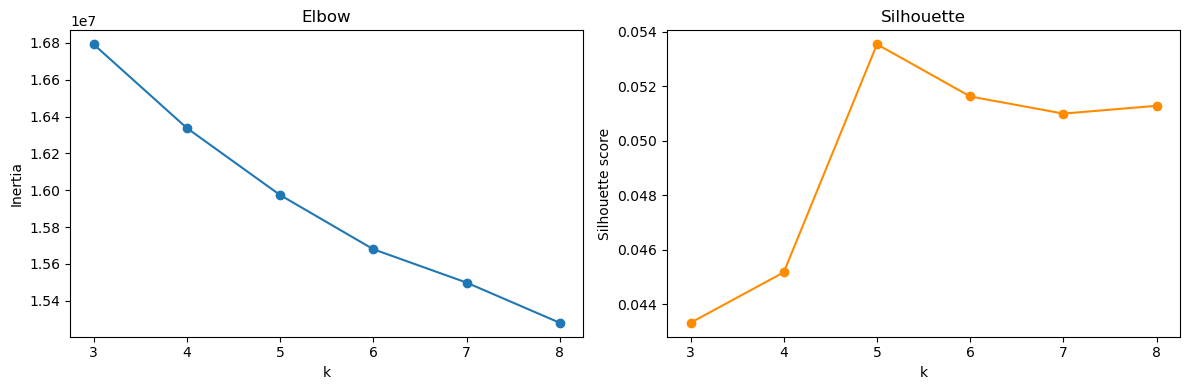

Best k by silhouette: 5  (score=0.054)


In [17]:
# Silhouette-guided k selection
K_RANGE = range(3, 9)
inertias, sil_scores = [], []

for k in tqdm(K_RANGE, desc='k-means sweep'):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbls = km.fit_predict(emb_matrix)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(emb_matrix, lbls, sample_size=3000, random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias, 'o-')
ax1.set_xlabel('k');  ax1.set_ylabel('Inertia');  ax1.set_title('Elbow')
ax2.plot(list(K_RANGE), sil_scores, 'o-', color='darkorange')
ax2.set_xlabel('k');  ax2.set_ylabel('Silhouette score');  ax2.set_title('Silhouette')
plt.tight_layout()
plt.savefig(FIGURES / 'dino_cluster_selection.png', dpi=150)
plt.show()

BEST_K = list(K_RANGE)[np.argmax(sil_scores)]
print(f"Best k by silhouette: {BEST_K}  (score={max(sil_scores):.3f})")

/var/folders/rk/jv2f_96j46v5vnvmjd2zk_1r0000gn/T/ipykernel_91647/1484479091.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', BEST_K)


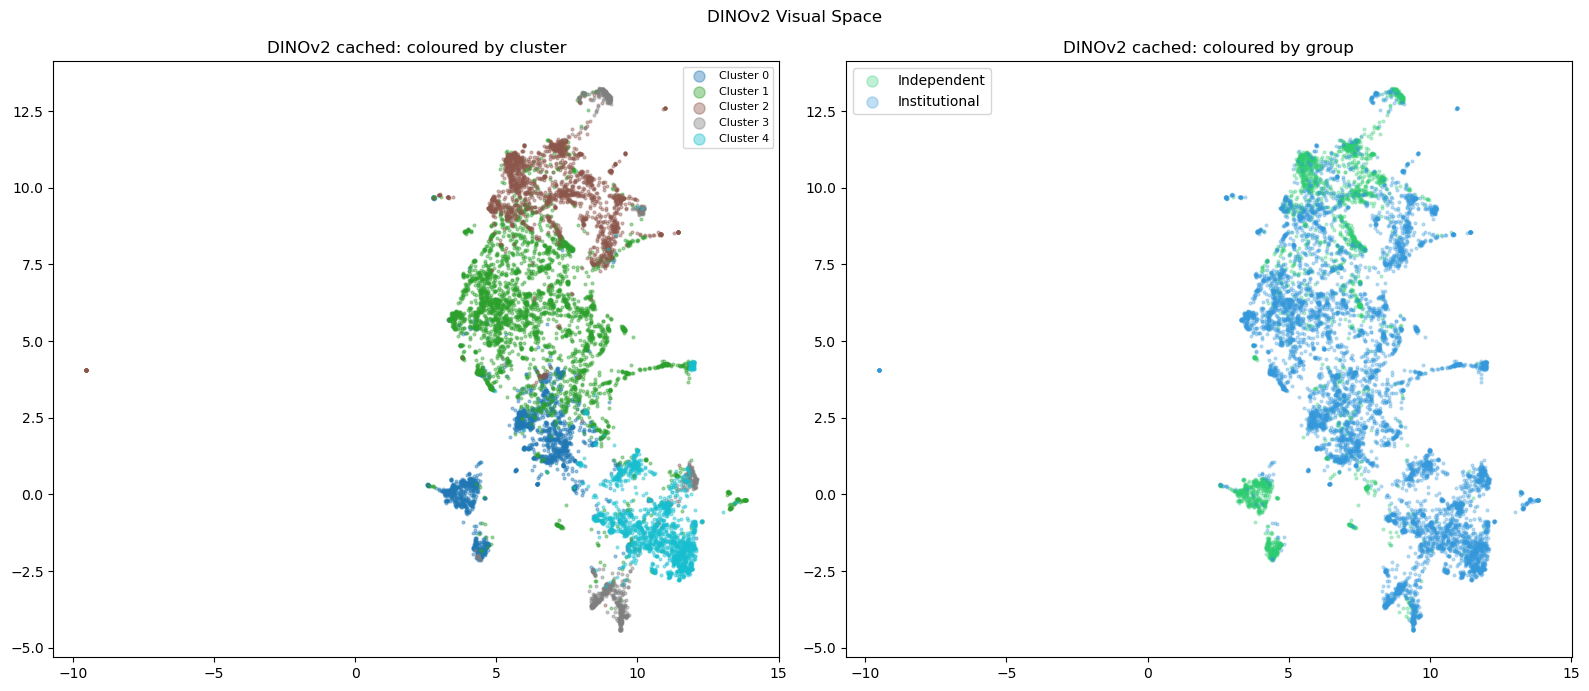

In [18]:
# Final clustering
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(emb_matrix)

dino_df = pd.DataFrame({
    'video_id':    dino_ids,
    'dino_cluster': cluster_labels,
    'proj_x':      emb_2d[:, 0],
    'proj_y':      emb_2d[:, 1],
}).merge(manifest[['video_id', 'group_label', 'channel_title']], on='video_id')

dino_df.to_csv(TABLES / 'dino_clusters.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cmap = plt.cm.get_cmap('tab10', BEST_K)

for c in range(BEST_K):
    mask = dino_df['dino_cluster'] == c
    axes[0].scatter(dino_df.loc[mask, 'proj_x'], dino_df.loc[mask, 'proj_y'],
                    s=4, alpha=0.4, color=cmap(c), label=f'Cluster {c}')
axes[0].set_title(f'DINOv2 {dim_method}: coloured by cluster')
axes[0].legend(markerscale=4, fontsize=8)

for grp, color in PALETTE.items():
    mask = dino_df['group_label'].str.lower() == grp
    axes[1].scatter(dino_df.loc[mask, 'proj_x'], dino_df.loc[mask, 'proj_y'],
                    s=4, alpha=0.3, color=color, label=grp.title())
axes[1].set_title(f'DINOv2 {dim_method}: coloured by group')
axes[1].legend(markerscale=4)

plt.suptitle('DINOv2 Visual Space')
plt.tight_layout()
plt.savefig(FIGURES / 'dino_umap_clusters.png', dpi=150)
plt.show()

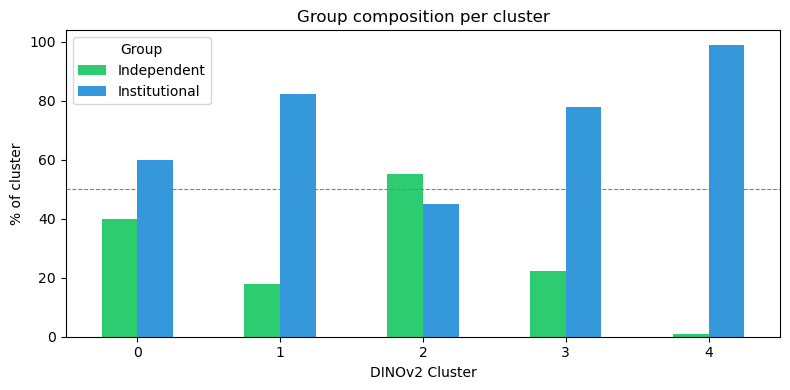

group_label   independent  institutional  total  independent_pct  institutional_pct
dino_cluster                                                                       
0                     729           1100   1829             39.9               60.1
1                     621           2872   3493             17.8               82.2
2                    1010            823   1833             55.1               44.9
3                     172            603    775             22.2               77.8
4                      16           1622   1638              1.0               99.0


In [19]:
# Cluster composition: which group dominates each cluster?
comp = (
    dino_df.groupby(['dino_cluster', 'group_label'])
    .size()
    .unstack(fill_value=0)
)
comp['total'] = comp.sum(axis=1)
for col in ['independent', 'institutional']:
    if col in comp.columns:
        comp[f'{col}_pct'] = (comp[col] / comp['total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
pct_cols = [c for c in comp.columns if c.endswith('_pct')]
comp[pct_cols].rename(columns=lambda c: c.replace('_pct', '').title()).plot(
    kind='bar', ax=ax,
    color=[PALETTE.get(c.replace('_pct', '').lower(), 'grey') for c in pct_cols],
    rot=0
)
ax.axhline(50, color='grey', linestyle='--', linewidth=0.8)
ax.set_ylabel('% of cluster')
ax.set_xlabel('DINOv2 Cluster')
ax.set_title('Group composition per cluster')
ax.legend(title='Group')
plt.tight_layout()
plt.savefig(FIGURES / 'dino_cluster_composition.png', dpi=150)
plt.show()
print(comp.to_string())

### 2b — Face-to-Canvas Ratio (OpenCV Haar cascade)

Cascade loaded from: /Users/alexlag/miniconda3/envs/ada2025/share/opencv4/haarcascades/haarcascade_frontalface_default.xml
Loaded cached face ratios: 9568 rows


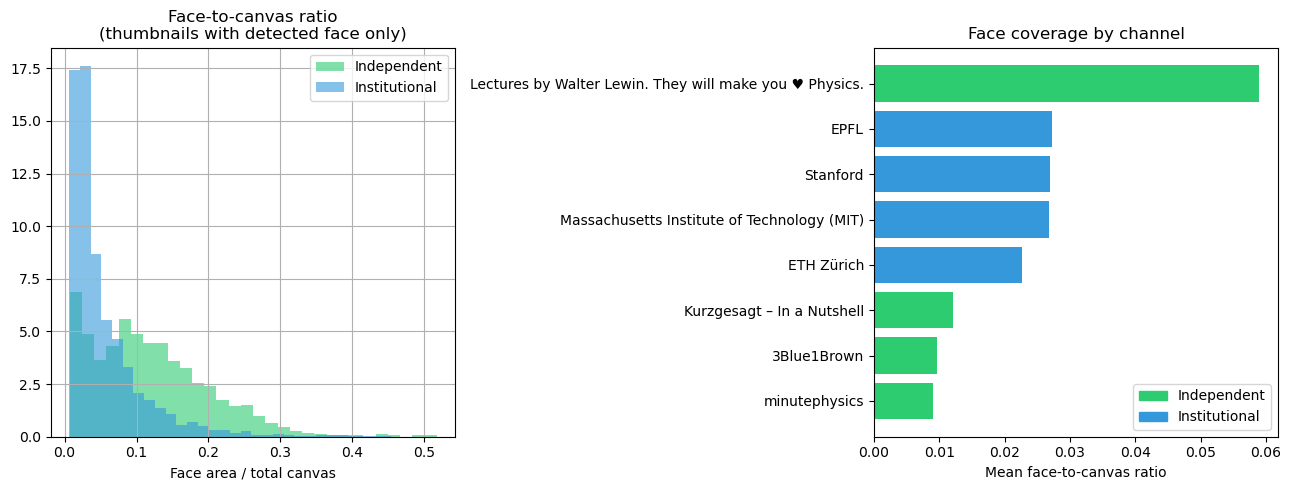

               face_canvas_ratio  n_faces_detected
group_label                                       
independent                0.042             0.434
institutional              0.026             0.628


In [20]:
FACE_RATIO_CACHE = TABLES / 'face_canvas_ratio.csv'

def _find_cascade(filename: str) -> str:
    import sys, os
    candidates = []
    # cv2.data (full opencv-python)
    if hasattr(cv2, 'data') and hasattr(cv2.data, 'haarcascades'):
        candidates.append(cv2.data.haarcascades + filename)
    # conda share/ tree — where opencv-python-headless puts them
    prefix = sys.prefix
    for sub in ['share/opencv4/haarcascades', 'share/OpenCV/haarcascades']:
        candidates.append(os.path.join(prefix, sub, filename))
    # cv2 package data dir
    cv2_dir = os.path.dirname(cv2.__file__)
    for sub in ['data', os.path.join('cv2', 'data'), '']:
        candidates.append(os.path.join(cv2_dir, sub, filename))
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f'{filename} not found. Tried:\n' + '\n'.join(f'  {p}' for p in candidates))

CASCADE_PATH = _find_cascade('haarcascade_frontalface_default.xml')
face_cascade = cv2.CascadeClassifier(CASCADE_PATH)
print(f'Cascade loaded from: {CASCADE_PATH}')

def face_canvas_ratio(path: str) -> tuple[float, int]:
    img = cv2.imread(path)
    if img is None:
        return 0.0, 0
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30)
    )
    if len(faces) == 0:
        return 0.0, 0
    face_area = sum(fw * fh for (_, _, fw, fh) in faces)
    return min(float(face_area) / (h * w), 1.0), len(faces)

if FACE_RATIO_CACHE.exists():
    face_df = pd.read_csv(FACE_RATIO_CACHE)
    print(f'Loaded cached face ratios: {len(face_df)} rows')
else:
    face_rows = []
    for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc='Face detection'):
        ratio, n_faces = face_canvas_ratio(row['thumb_path'])
        face_rows.append({
            'video_id':          row['video_id'],
            'face_canvas_ratio': ratio,
            'n_faces_detected':  n_faces,
        })
    face_df = pd.DataFrame(face_rows)
    face_df.to_csv(FACE_RATIO_CACHE, index=False)
    print(f'Saved face ratios: {len(face_df)} rows')

face_df = face_df.merge(manifest[['video_id', 'group_label', 'channel_title']], on='video_id')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for grp, color in PALETTE.items():
    vals = face_df[face_df['group_label'].str.lower() == grp]['face_canvas_ratio']
    vals[vals > 0].hist(ax=axes[0], bins=30, alpha=0.6, color=color,
                        label=grp.title(), density=True)
axes[0].set_xlabel('Face area / total canvas')
axes[0].set_title('Face-to-canvas ratio\n(thumbnails with detected face only)')
axes[0].legend()

ch_face = face_df.groupby(['channel_title', 'group_label'])['face_canvas_ratio'].mean().reset_index()
ch_face = ch_face.sort_values('face_canvas_ratio')
axes[1].barh(ch_face['channel_title'], ch_face['face_canvas_ratio'],
             color=[PALETTE.get(g.lower(), 'grey') for g in ch_face['group_label']])
axes[1].set_xlabel('Mean face-to-canvas ratio')
axes[1].set_title('Face coverage by channel')
axes[1].legend(handles=[mpatches.Patch(color=v, label=k.title()) for k, v in PALETTE.items()])

plt.tight_layout()
plt.savefig(FIGURES / 'face_canvas_ratio.png', dpi=150)
plt.show()

print(face_df.groupby('group_label')[['face_canvas_ratio', 'n_faces_detected']].mean().round(3))

### 2c — Text Placement Zone (edge-density proxy)

Loaded cached zone data: 9568 rows


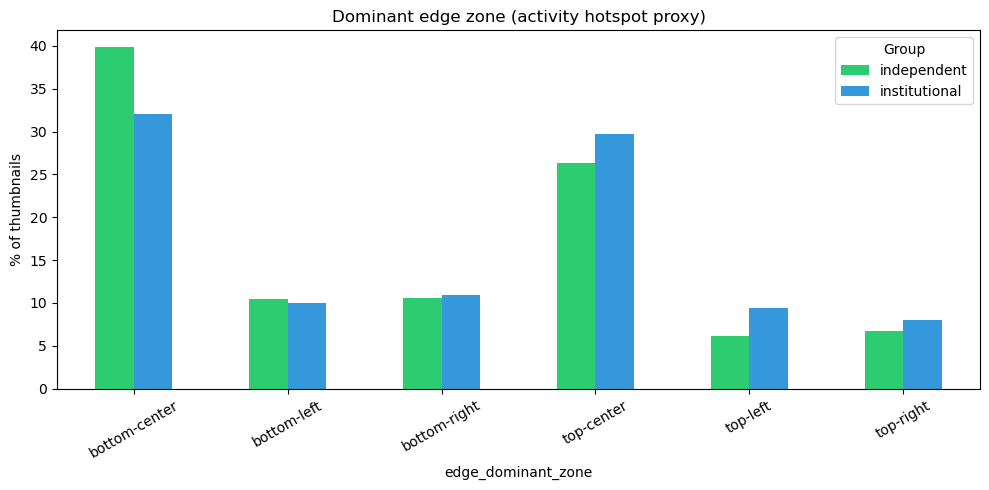

In [21]:
ZONE_CACHE = TABLES / 'text_placement_zone.csv'

ZONE_GRID = {
    'top-left':      (0.0, 0.0, 0.33, 0.5),
    'top-center':    (0.33, 0.0, 0.67, 0.5),
    'top-right':     (0.67, 0.0, 1.0, 0.5),
    'bottom-left':   (0.0, 0.5, 0.33, 1.0),
    'bottom-center': (0.33, 0.5, 0.67, 1.0),
    'bottom-right':  (0.67, 0.5, 1.0, 1.0),
}

def dominant_edge_zone(path: str) -> str:
    """Grid zone with highest Canny edge density — rough proxy for text/activity hotspot."""
    img = cv2.imread(path)
    if img is None:
        return 'unknown'
    h, w = img.shape[:2]
    edges = cv2.Canny(img, 100, 200).astype(float)
    best_zone, best_val = 'unknown', -1.0
    for zone, (x0, y0, x1, y1) in ZONE_GRID.items():
        patch = edges[int(y0*h):int(y1*h), int(x0*w):int(x1*w)]
        val = patch.mean()
        if val > best_val:
            best_val, best_zone = val, zone
    return best_zone

if ZONE_CACHE.exists():
    zone_df = pd.read_csv(ZONE_CACHE)
    print(f"Loaded cached zone data: {len(zone_df)} rows")
else:
    zone_rows = []
    for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc='Text zone'):
        zone_rows.append({
            'video_id': row['video_id'],
            'edge_dominant_zone': dominant_edge_zone(row['thumb_path'])
        })
    zone_df = pd.DataFrame(zone_rows)
    zone_df.to_csv(ZONE_CACHE, index=False)

zone_df = zone_df.merge(manifest[['video_id', 'group_label', 'channel_title']], on='video_id')

zone_pct = (
    zone_df.groupby(['group_label', 'edge_dominant_zone'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
)

fig, ax = plt.subplots(figsize=(10, 5))
zone_pct.T.plot(kind='bar', ax=ax,
                color=[PALETTE.get(g.lower(), 'grey') for g in zone_pct.index], rot=30)
ax.set_ylabel('% of thumbnails')
ax.set_title('Dominant edge zone (activity hotspot proxy)')
ax.legend(title='Group')
plt.tight_layout()
plt.savefig(FIGURES / 'edge_dominant_zone.png', dpi=150)
plt.show()

---
## SYNTHESIS — Cross-reference Tracks & Define Archetypes

Each VLM-analysed thumbnail is mapped to its DINOv2 cluster. We profile each cluster on both semantic (VLM) and visual/spatial (DINOv2 + OpenCV) dimensions to name a Thumbnail Archetype.

In [22]:
# Load any dataframe from cache if an earlier cell was skipped or failed
if 'face_df' not in vars() and FACE_RATIO_CACHE.exists():
    face_df = pd.read_csv(FACE_RATIO_CACHE).merge(
        manifest[['video_id', 'group_label', 'channel_title']], on='video_id'
    )
    print(f'Loaded face_df from cache ({len(face_df)} rows)')

if 'zone_df' not in vars() and ZONE_CACHE.exists():
    zone_df = pd.read_csv(ZONE_CACHE).merge(
        manifest[['video_id', 'group_label', 'channel_title']], on='video_id'
    )
    print(f'Loaded zone_df from cache ({len(zone_df)} rows)')

# Merge VLM annotations ← DINOv2 clusters ← face ratio ← zone
synth_df = (
    vlm_df
    .merge(dino_df[['video_id', 'dino_cluster', 'proj_x', 'proj_y']], on='video_id', how='left')
    .merge(face_df[['video_id', 'face_canvas_ratio', 'n_faces_detected']],  on='video_id', how='left')
    .merge(zone_df[['video_id', 'edge_dominant_zone']], on='video_id', how='left')
)

print(f"Synthesis dataset: {len(synth_df)} rows")
print(f"Cluster coverage: {synth_df['dino_cluster'].notna().sum()} / {len(synth_df)} rows mapped")
synth_df.head(3)

Synthesis dataset: 9486 rows
Cluster coverage: 9486 / 9486 rows mapped


,video_id,channel_title,group_label,embedded_text,text_function,primary_scientific_subject,visual_presentation_style,text_placement_zone,hp_is_present,hp_count,...,hp_dominant_emotion,cb_has_red_arrow,cb_has_exag_contrast,cb_sensationalism_score,dino_cluster,proj_x,proj_y,face_canvas_ratio,n_faces_detected,edge_dominant_zone
0,w-CXIqIjfRI,3Blue1Brown,independent,Levels of u\nWhat is it saying?\nWhy is it tru...,question,Bayesian inference,academic_lecture,top,False,0,...,none,False,False,1,2,8.057265,9.743777,0.0,0,top-left
1,Iq1a_KJTWJ8,3Blue1Brown,independent,\frac{\sin(\theta_1)}{v_1} = \frac{\sin(\theta...,factual_statement,wave mechanics,academic_lecture,center,False,0,...,none,False,False,1,2,7.988138,10.470179,0.0,0,top-center
2,1lZpowy21Gc,3Blue1Brown,independent,NaN,none,minimalist_text,stock_photography,none,False,0,...,none,False,False,1,1,6.291871,7.593975,0.0,0,top-center


In [23]:
# Profile each DINOv2 cluster across both tracks
def mode(s):
    return s.mode().iloc[0] if len(s) > 0 else 'N/A'

profile_agg = {
    'text_function':              mode,
    'visual_presentation_style':  mode,
    'hp_is_present':              'mean',
    'hp_canvas_coverage_pct':     'mean',
    'hp_dominant_emotion':        mode,
    'cb_sensationalism_score':    'mean',
    'cb_has_red_arrow':           'mean',
    'face_canvas_ratio':          'mean',
    'edge_dominant_zone':         mode,
    'group_label':                mode,   # dominant group in that cluster
}

cluster_profiles = (
    synth_df.dropna(subset=['dino_cluster'])
    .groupby('dino_cluster')
    .agg(profile_agg)
    .round(2)
)
cluster_profiles.columns = [
    'text_fn', 'style', 'face_pct', 'coverage', 'emotion',
    'sensation', 'arrow_pct', 'face_ratio', 'zone', 'dom_group'
]
print(cluster_profiles.to_string())

                        text_fn              style  face_pct  coverage                 emotion  sensation  arrow_pct  face_ratio           zone      dom_group
dino_cluster                                                                                                                                                  
0                          none   academic_lecture      1.00     46.98                 neutral       1.28       0.01        0.10  bottom-center  institutional
1                          none  stock_photography      0.69     24.56                 neutral       1.43       0.01        0.01  bottom-center  institutional
2             factual_statement   academic_lecture      0.23      6.11                    none       1.91       0.06        0.01  bottom-center    independent
3             factual_statement   academic_lecture      0.94     27.62                 neutral       1.09       0.04        0.01     top-center  institutional
4                          none   academic_lec

In [ ]:
# Suggest archetype names based on cluster profiles
# ── Edit these labels after inspecting the profile table above ──────────────
ARCHETYPE_NAMES = {
    0: 'Neutral Full-Frame Presenter',
    1: 'Institutional Stock Photo',
    2: 'Minimalist Factual Slide',
    3: 'Presenter + Statement Caption',
    4: 'Intense Close-Up Hook',
}

if ARCHETYPE_NAMES:
    synth_df['archetype'] = synth_df['dino_cluster'].map(ARCHETYPE_NAMES).fillna('Unassigned')
    dino_df['archetype']  = dino_df['dino_cluster'].map(ARCHETYPE_NAMES).fillna('Unassigned')
    print("Archetypes mapped. Counts:")
    print(synth_df['archetype'].value_counts())
else:
    print(" Fill in ARCHETYPE_NAMES above after inspecting cluster_profiles, then re-run.")

Archetypes mapped. Counts:
archetype
Institutional Stock Photo        3488
Neutral Full-Frame Presenter     1809
Minimalist Factual Slide         1804
Intense Close-Up Hook            1635
Presenter + Statement Caption     750
Name: count, dtype: int64


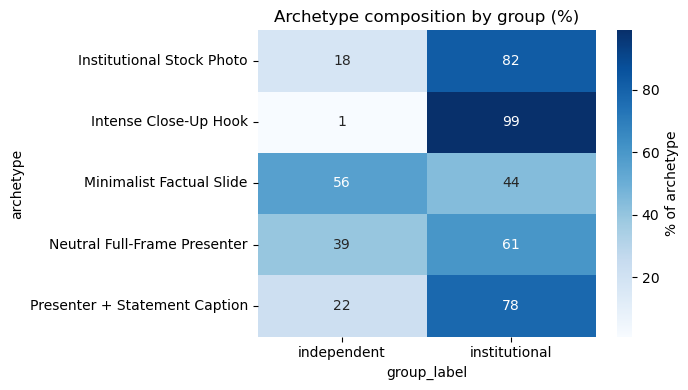

In [ ]:
# Heatmap: archetype × group_label 
if 'archetype' in synth_df.columns and synth_df['archetype'].ne('Unassigned').any():
    cross = pd.crosstab(
        synth_df['archetype'],
        synth_df['group_label'],
        normalize='index'
    ) * 100

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(cross, annot=True, fmt='.0f', cmap='Blues', ax=ax,
                cbar_kws={'label': '% of archetype'})
    ax.set_title('Archetype composition by group (%)')
    plt.tight_layout()
    plt.savefig(FIGURES / 'archetype_group_heatmap.png', dpi=150)
    plt.show()
else:
    print("Define ARCHETYPE_NAMES above first.")

/var/folders/rk/jv2f_96j46v5vnvmjd2zk_1r0000gn/T/ipykernel_91647/797494527.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('tab10', len(radar_df))


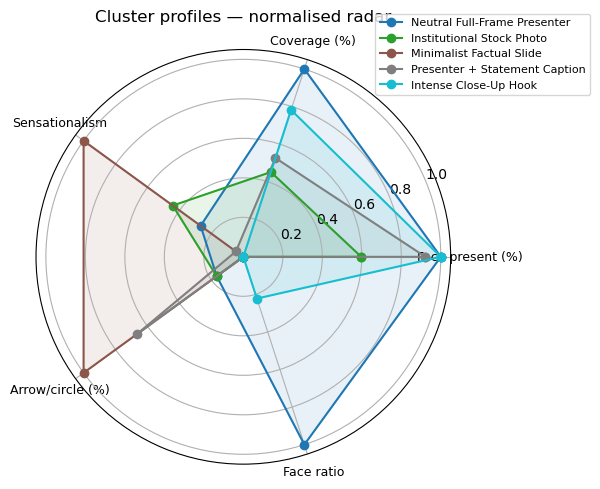

In [31]:
# ── Radar / spider chart: cluster profiles on 5 numeric axes ────────────────
numeric_axes = {
    'Face present (%)':   'face_pct',
    'Coverage (%)':       'coverage',
    'Sensationalism':     'sensation',
    'Arrow/circle (%)':   'arrow_pct',
    'Face ratio':         'face_ratio',
}

# Normalise 0–1 for radar
radar_df = cluster_profiles[list(numeric_axes.values())].copy()
for col in radar_df.columns:
    vmin, vmax = radar_df[col].min(), radar_df[col].max()
    radar_df[col] = (radar_df[col] - vmin) / (vmax - vmin + 1e-9)

labels  = list(numeric_axes.keys())
N       = len(labels)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig = plt.figure(figsize=(10, 5))
cmap_r = plt.cm.get_cmap('tab10', len(radar_df))

ax = fig.add_subplot(111, polar=True)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=9)

for idx, (cluster_id, row) in enumerate(radar_df.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    label = ARCHETYPE_NAMES.get(cluster_id, f'Cluster {cluster_id}')
    ax.plot(angles, values, 'o-', linewidth=1.5, color=cmap_r(idx), label=label)
    ax.fill(angles, values, alpha=0.1, color=cmap_r(idx))

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
ax.set_title('Cluster profiles — normalised radar', pad=20)
plt.tight_layout()
plt.savefig(FIGURES / 'archetype_radar.png', dpi=150)
plt.show()

/var/folders/rk/jv2f_96j46v5vnvmjd2zk_1r0000gn/T/ipykernel_91647/3142937772.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_f = plt.cm.get_cmap('tab10', len(unique_vals))


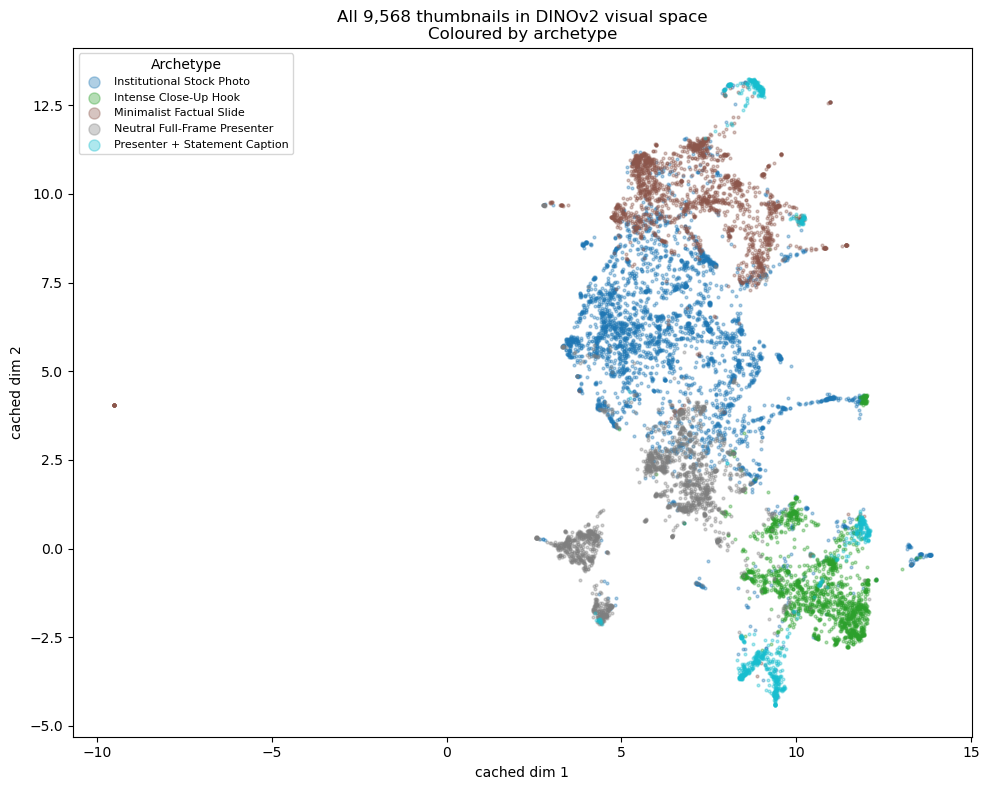

In [32]:
# ── Final UMAP scatter coloured by archetype (if named) ──────────────────────
plot_df = dino_df.copy()
color_col = 'archetype' if 'archetype' in plot_df.columns else 'dino_cluster'
unique_vals = plot_df[color_col].unique()
cmap_f = plt.cm.get_cmap('tab10', len(unique_vals))
val_to_color = {v: cmap_f(i) for i, v in enumerate(sorted(unique_vals, key=str))}

fig, ax = plt.subplots(figsize=(10, 8))
for val, color in val_to_color.items():
    mask = plot_df[color_col] == val
    ax.scatter(plot_df.loc[mask, 'proj_x'], plot_df.loc[mask, 'proj_y'],
               s=4, alpha=0.35, color=color, label=str(val))

ax.legend(markerscale=4, fontsize=8, title=color_col.replace('_', ' ').title())
ax.set_title(f'All {len(plot_df):,} thumbnails in DINOv2 visual space\nColoured by {color_col}')
ax.set_xlabel(dim_method + ' dim 1')
ax.set_ylabel(dim_method + ' dim 2')
plt.tight_layout()
plt.savefig(FIGURES / 'final_archetype_map.png', dpi=150)
plt.show()

In [ ]:
# ── UMAP scatter coloured by channel ─────────────────────────────────────────
channels = sorted(dino_df['channel_title'].unique())
ch_cmap  = plt.cm.get_cmap('tab10', len(channels))
ch_color = {ch: ch_cmap(i) for i, ch in enumerate(channels)}

fig, ax = plt.subplots(figsize=(11, 8))
for ch in channels:
    mask = dino_df['channel_title'] == ch
    ax.scatter(dino_df.loc[mask, 'proj_x'], dino_df.loc[mask, 'proj_y'],
               s=4, alpha=0.35, color=ch_color[ch], label=ch)

ax.legend(markerscale=4, fontsize=7, title='Channel',
          loc='upper left', bbox_to_anchor=(1.01, 1))
ax.set_title(f'All {len(dino_df):,} thumbnails in DINOv2 visual space\nColoured by channel')
ax.set_xlabel(dim_method + ' dim 1')
ax.set_ylabel(dim_method + ' dim 2')
plt.tight_layout()
plt.savefig(FIGURES / 'dino_umap_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── Save synthesis dataset ───────────────────────────────────────────────────
synth_df.to_csv(TABLES / 'advanced_thumbnail_synthesis.csv', index=False)

# Summary statistics table
summary = (
    synth_df.groupby('group_label').agg(
        n                   = ('video_id',                'count'),
        pct_with_face       = ('hp_is_present',           'mean'),
        mean_coverage_pct   = ('hp_canvas_coverage_pct',  'mean'),
        pct_question_hook   = ('text_function',            lambda x: (x.isin(['question','hyperbolic_hook'])).mean()),
        pct_factual         = ('text_function',            lambda x: (x == 'factual_statement').mean()),
        mean_sensation      = ('cb_sensationalism_score',  'mean'),
        pct_vlog_selfie     = ('visual_presentation_style',lambda x: (x == 'vlog_selfie').mean()),
        mean_face_ratio_cv  = ('face_canvas_ratio',        'mean'),
    ).round(3).T
)
summary.to_csv(TABLES / 'advanced_thumbnail_summary.csv')
print(summary.to_string())

group_label         independent  institutional
n                      2521.000       6965.000
pct_with_face             0.581          0.792
mean_coverage_pct        23.590         29.459
pct_question_hook         0.244          0.056
pct_factual               0.228          0.229
mean_sensation            1.824          1.249
pct_vlog_selfie           0.188          0.044
mean_face_ratio_cv        0.042          0.026
